# 목표

뉴스의 카테고리 예측

In [1]:
# %load_ext colablinter

In [2]:
import os

ROOT_DIR = os.getcwd()
TRAIN_DIR = os.path.join(ROOT_DIR, "data", "20news-bydate-train")
TEST_DIR = os.path.join(ROOT_DIR, "data", "20news-bydate-test")

In [3]:
train_category_set = set(os.listdir(TRAIN_DIR))
test_category_set = set(os.listdir(TEST_DIR))

only_in_train = train_category_set - test_category_set
only_in_test = test_category_set - train_category_set

print(f"· 학습 데이터에만 있는 카테고리: {len(only_in_train)}개")
print(f"· 테스트 데이터에만 있는 카테고리: {len(only_in_test)}개")

· 학습 데이터에만 있는 카테고리: 0개
· 테스트 데이터에만 있는 카테고리: 0개


In [4]:
import io
from glob import glob

TRAIN_DICT = dict()

paths = glob(os.path.join(TRAIN_DIR, "**"), recursive=True)

for path_ in paths:
    if os.path.isfile(path_):
        with open(path_, "r", encoding="utf-8") as f:
            if type(f) == io.TextIOWrapper:
                category = os.path.dirname(path_).split("/")[-1]
                if category in TRAIN_DICT.keys():
                    TRAIN_DICT[category].append(path_)
                else:
                    TRAIN_DICT[category] = [path_]

In [5]:
TRAIN_DICT = dict()
TEST_DICT = dict()

for category in os.listdir(TRAIN_DIR):
    TRAIN_DICT[category] = [path_ for path_ in glob(os.path.join(TRAIN_DIR, category, "*")) if os.path.isfile(path_)]

for category in os.listdir(TEST_DIR):
    TEST_DICT[category] = [path_ for path_ in glob(os.path.join(TEST_DIR, category, "*")) if os.path.isfile(path_)]

print(f"· 학습 데이터: {sum([len(a) for a in TRAIN_DICT.values()])}개")
print(f"· 테스트 데이터: {sum([len(a) for a in TEST_DICT.values()])}개")

· 학습 데이터: 11314개
· 테스트 데이터: 7532개


학습 데이터에 비해 테스트 데이터가 너무 많은 듯?

In [6]:
print("[클래스별 데이터]")

i = 0
for key, value in TRAIN_DICT.items():
    i += 1
    print(f"{i}) {key}: {len(value)}개")

[클래스별 데이터]
1) talk.politics.mideast: 564개
2) rec.autos: 594개
3) comp.sys.mac.hardware: 578개
4) alt.atheism: 480개
5) rec.sport.baseball: 597개
6) comp.os.ms-windows.misc: 591개
7) rec.sport.hockey: 600개
8) sci.crypt: 595개
9) sci.med: 594개
10) talk.politics.misc: 465개
11) rec.motorcycles: 598개
12) comp.windows.x: 593개
13) comp.graphics: 584개
14) comp.sys.ibm.pc.hardware: 590개
15) sci.electronics: 591개
16) talk.politics.guns: 546개
17) sci.space: 593개
18) soc.religion.christian: 599개
19) misc.forsale: 585개
20) talk.religion.misc: 377개


상위 하위 클래스로 구성되어 있으니, 클래스도 더 나눠보자.

misc는 잡동사니라는 뜻으로, 주요 카테고리가 아니라는 뜻이다.

끝의 카테고리를 main이라고 하나 만들자.

religion은 talk와 society에 겹친다.

In [ ]:
category_detail_dict = dict()

for category in TRAIN_DICT.keys():
    splited_category = category.split(".")

    if splited_category[-1] != "misc":
        splited_category.append("main")


    category_detail_dict[category] = dict()
    
    for i in range(1, len(splited_category)):
        category_detail_dict[category]["super_category"] = splited_category[0]
        category_detail_dict[category][i] = splited_category[i]

In [17]:
import plotly.graph_objects as go

# 데이터
data = category_detail_dict

# 트리 구조 생성 - 레벨별로 노드 이름만 기준으로 병합
nodes_by_level_and_name = {}  # (level, name) -> node_key
nodes = {}
edges = set()  # 중복 제거를 위해 set 사용
node_id = 0

# 루트 노드
root_key = ('ROOT', 0)
nodes[root_key] = {'id': node_id, 'label': 'ROOT', 'level': 0}
nodes_by_level_and_name[(0, 'ROOT')] = root_key
node_id += 1

# 모든 경로 처리
for category, path_dict in data.items():
    super_cat = path_dict['super_category']
    
    # super_category 노드 추가 (레벨 1)
    level_name_key = (1, super_cat)
    if level_name_key not in nodes_by_level_and_name:
        node_key = (super_cat, 1)
        nodes[node_key] = {'id': node_id, 'label': super_cat, 'level': 1}
        nodes_by_level_and_name[level_name_key] = node_key
        edges.add((root_key, node_key))
        node_id += 1
    
    parent_key = nodes_by_level_and_name[level_name_key]
    
    # 하위 경로 구성
    max_level = max([k for k in path_dict.keys() if isinstance(k, int)])
    
    for i in range(1, max_level + 1):
        if i in path_dict:
            current_name = path_dict[i]
            current_level = i + 1
            level_name_key = (current_level, current_name)
            
            # 같은 레벨에 같은 이름의 노드가 없으면 새로 생성
            if level_name_key not in nodes_by_level_and_name:
                node_key = (current_name, current_level)
                nodes[node_key] = {'id': node_id, 'label': current_name, 'level': current_level}
                nodes_by_level_and_name[level_name_key] = node_key
                node_id += 1
            
            current_key = nodes_by_level_and_name[level_name_key]
            edges.add((parent_key, current_key))
            parent_key = current_key

# 레벨별로 노드 그룹화
levels = {}
for node_key, node in nodes.items():
    level = node['level']
    if level not in levels:
        levels[level] = []
    levels[level].append(node_key)

# 좌표 계산
for level, node_keys in levels.items():
    num_nodes = len(node_keys)
    y = -level * 2
    
    for i, key in enumerate(node_keys):
        if num_nodes == 1:
            x = 0
        else:
            spacing = min(15, 50 / num_nodes)
            x = (i - (num_nodes - 1) / 2) * spacing
        
        nodes[key]['x'] = x
        nodes[key]['y'] = y

# 엣지 데이터 생성
edge_x = []
edge_y = []
for parent, child in edges:
    edge_x.extend([nodes[parent]['x'], nodes[child]['x'], None])
    edge_y.extend([nodes[parent]['y'], nodes[child]['y'], None])

# 엣지 trace
edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode='lines',
    line=dict(width=1.5, color='#cccccc'),
    hoverinfo='none'
)

# 노드 데이터
node_x = [n['x'] for n in nodes.values()]
node_y = [n['y'] for n in nodes.values()]
node_text = [n['label'] for n in nodes.values()]

# 레벨별 색상
node_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
node_color = [node_colors[n['level'] % len(node_colors)] for n in nodes.values()]

# 각 노드의 연결 수 계산 (부모 수)
parent_counts = {}
for parent, child in edges:
    if child not in parent_counts:
        parent_counts[child] = 0
    parent_counts[child] += 1

hover_text = []
for node_key, n in nodes.items():
    parent_count = parent_counts.get(node_key, 0)
    if parent_count > 1:
        hover_text.append(f"{n['label']}<br>레벨: {n['level']}<br>부모 노드: {parent_count}개")
    else:
        hover_text.append(f"{n['label']}<br>레벨: {n['level']}")

# 노드 trace
node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers+text',
    text=node_text,
    textposition='top center',
    textfont=dict(size=10, color='black', family='Arial'),
    marker=dict(
        size=18,
        color=node_color,
        line=dict(width=2, color='white')
    ),
    hoverinfo='text',
    hovertext=hover_text
)

# 레이아웃
layout = go.Layout(
    title=dict(text='카테고리 계층 구조 (중복 노드 병합)', font=dict(size=20)),
    showlegend=False,
    hovermode='closest',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    margin=dict(l=40, r=40, t=60, b=40),
    height=900,
)

# 그래프 생성
fig = go.Figure(data=[edge_trace, node_trace], layout=layout)
fig.show()

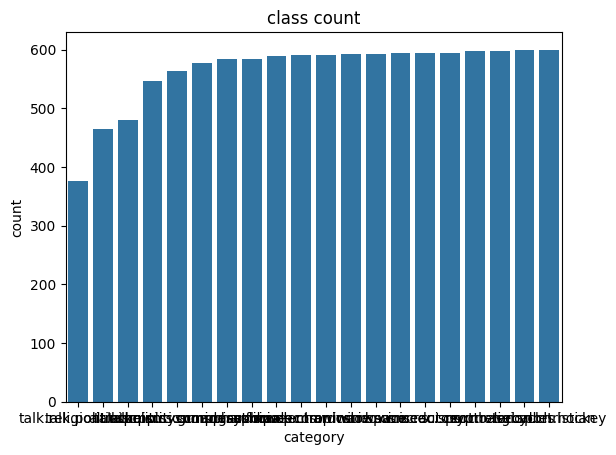

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class_df = pd.DataFrame(columns=["category", "count"])

for key, value in TRAIN_DICT.items():
    class_df.loc[len(class_df)] = [key, len(value)]

class_df = class_df.sort_values(ascending=True, by="count")
sns.barplot(data=class_df, x="category", y="count")
plt.title("class count")
plt.show()

talk.religion.misc 클래스가 좀 적네

In [11]:
def get_text(path):
    with open(path, "r", encoding="utf-8") as f:
        data = f.read()
        
    return data

In [12]:
import random

rand_key_idx = random.randint(1, len(TRAIN_DICT.keys()))
rand_key = list(TRAIN_DICT.keys())[rand_key_idx - 1]
rand_value_idx = random.randint(1, len(TRAIN_DICT[rand_key]))

sample_text = get_text(TRAIN_DICT[rand_key][rand_value_idx - 1])

print(f"[샘플 출력 (label: {rand_key})]")
print("=" * 20)
print(sample_text)

[샘플 출력 (label: rec.sport.hockey)]
From: gp2011@andy.bgsu.edu (George Pavlic)
Subject: Re: Aargh!  Great Hockey Coverage!! (Devils)
Organization: Bowling Green State University B.G., Oh.
Lines: 22

In article <1993Apr18.203823.28597@news.columbia.edu>,
gld@cunixb.cc.columbia.edu (Gary L Dare) wrote:
> 
> 
> Locked away, waiting for the tape-delay to start ...
> 
> It's nice that the Devils are starting out their playoffs on network
> television ... too bad that their playoff game has been preempted on
> WABC-AM for an early-season Yankees baseball game!
> 
> It's a 12-2 win by the Texas Rangers ... and they're delaying the
> tape-delay by another half-hour for the ballgame "highlights"!!!
> 
You think that's bad?  I'm in Bowling Green, OH, and we get ABC from
Toledo.  Well, the cable co. decided to totally pre-empt the game (no tape
delay, no nothing) for a stupid telethon!  Hockey is very big around here,
too.  I had to listen to "my" Penguins win on my car radio out in the
parking lot

1. '>' 같은 기호들 (단, 부등호는 조심할 것)

2. 연락처 같은 것들로 카테고리를 외운다면, 정답은 잘 맞추겠지만 과적합일 가능성이 높아질 것 같다.

3. 이메일도 지우자.
